In [1]:
# CardioIA - Ir Além 2
## Comparação: Regressão Logística vs Rede Neural para detecção de risco cardíaco

In [2]:
!pip install tensorflow scikit-learn pandas numpy matplotlib seaborn -q
print("✅ Dependências instaladas!")

✅ Dependências instaladas!


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

np.random.seed(42)
tf.random.set_seed(42)
print("✅ Bibliotecas carregadas!")

✅ Bibliotecas carregadas!


In [4]:
# Gerar dados sintéticos de série temporal
n_amostras = 500
tempo = np.arange(n_amostras)

bpm_base = 75 + np.random.normal(0, 8, n_amostras)
picos = np.random.choice([0, 1], size=n_amostras, p=[0.88, 0.12])
bpm = bpm_base + picos * np.random.uniform(30, 60, n_amostras)
bpm = np.clip(bpm, 40, 190).astype(int)

temp_base = 36.4 + np.random.normal(0, 0.4, n_amostras)
febre = np.random.choice([0, 1], size=n_amostras, p=[0.94, 0.06])
temp = temp_base + febre * np.random.uniform(1.5, 3.0, n_amostras)
temp = np.round(np.clip(temp, 35, 40), 1)

umidade = np.random.randint(50, 85, n_amostras)

y = ((bpm > 120) | (temp > 38)).astype(int)

df = pd.DataFrame({'tempo': tempo, 'bpm': bpm, 'temperatura': temp, 'umidade': umidade, 'risco': y})
print(f"Total: {len(df)} amostras | Risco: {y.sum()} ({y.mean()*100:.1f}%) | Normal: {(1-y).sum()} ({(1-y).mean()*100:.1f}%)")

Total: 500 amostras | Risco: 60 (12.0%) | Normal: 440 (88.0%)


In [17]:
features = ['bpm', 'temperatura', 'umidade']
X = df[features].values
y = df['risco'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Treino: {len(X_train)} amostras | Teste: {len(X_test)} amostras")

Treino: 350 amostras | Teste: 150 amostras


In [16]:
features = ['bpm', 'temperatura', 'umidade']
X = df[features].values
y = df['risco'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Treino: {len(X_train)} amostras | Teste: {len(X_test)} amostras")

Treino: 350 amostras | Teste: 150 amostras


In [8]:
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)

acc_lr = accuracy_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr)
rec_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

print("REGRESSÃO LOGÍSTICA")
print("=" * 40)
print(f"Acurácia:  {acc_lr:.4f}")
print(f"Precisão:  {prec_lr:.4f}")
print(f"Recall:    {rec_lr:.4f}")
print(f"F1-Score:  {f1_lr:.4f}")
print(f"\nCoeficientes: BPM={lr_model.coef_[0][0]:.4f} | Temp={lr_model.coef_[0][1]:.4f} | Umidade={lr_model.coef_[0][2]:.4f}")
print(f"\n{classification_report(y_test, y_pred_lr, target_names=['Normal', 'Risco'])}")

REGRESSÃO LOGÍSTICA
Acurácia:  0.9733
Precisão:  1.0000
Recall:    0.7778
F1-Score:  0.8750

Coeficientes: BPM=2.1625 | Temp=2.3833 | Umidade=-0.1142

              precision    recall  f1-score   support

      Normal       0.97      1.00      0.99       132
       Risco       1.00      0.78      0.88        18

    accuracy                           0.97       150
   macro avg       0.99      0.89      0.93       150
weighted avg       0.97      0.97      0.97       150



## 2. Rede Neural

In [10]:
model = keras.Sequential([
    layers.Dense(16, activation='relu', input_shape=(3,)),
    layers.Dropout(0.2),
    layers.Dense(8, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 16)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 209 (836.00 B)

 Trainable params: 209 (836.00 B)

 Non-trainable params: 0 (0.00 B)

In [11]:
history = model.fit(X_train_scaled, y_train, epochs=50, batch_size=16,
                    validation_split=0.2, verbose=0)

y_prob_nn = model.predict(X_test_scaled, verbose=0)
y_pred_nn = (y_prob_nn > 0.5).astype(int).flatten()

acc_nn = accuracy_score(y_test, y_pred_nn)
prec_nn = precision_score(y_test, y_pred_nn)
rec_nn = recall_score(y_test, y_pred_nn)
f1_nn = f1_score(y_test, y_pred_nn)

print("REDE NEURAL")
print("=" * 40)
print(f"Acurácia:  {acc_nn:.4f}")
print(f"Precisão:  {prec_nn:.4f}")
print(f"Recall:    {rec_nn:.4f}")
print(f"F1-Score:  {f1_nn:.4f}")
print(f"\n{classification_report(y_test, y_pred_nn, target_names=['Normal', 'Risco'])}")

REDE NEURAL
Acurácia:  0.9667
Precisão:  0.9333
Recall:    0.7778
F1-Score:  0.8485

              precision    recall  f1-score   support

      Normal       0.97      0.99      0.98       132
       Risco       0.93      0.78      0.85        18

    accuracy                           0.97       150
   macro avg       0.95      0.89      0.91       150
weighted avg       0.97      0.97      0.97       150



## 3. Comparação dos Modelos

In [12]:
comparacao = pd.DataFrame({
    'Métrica': ['Acurácia', 'Precisão', 'Recall', 'F1-Score'],
    'Regressão Logística': [acc_lr, prec_lr, rec_lr, f1_lr],
    'Rede Neural': [acc_nn, prec_nn, rec_nn, f1_nn]
})
comparacao['Diferença'] = comparacao['Rede Neural'] - comparacao['Regressão Logística']
comparacao

,Métrica,Regressão Logística,Rede Neural,Diferença
0,Acurácia,0.973333,0.966667,-0.006667
1,Precisão,1.000000,0.933333,-0.066667
2,Recall,0.777778,0.777778,0.000000
3,F1-Score,0.875000,0.848485,-0.026515


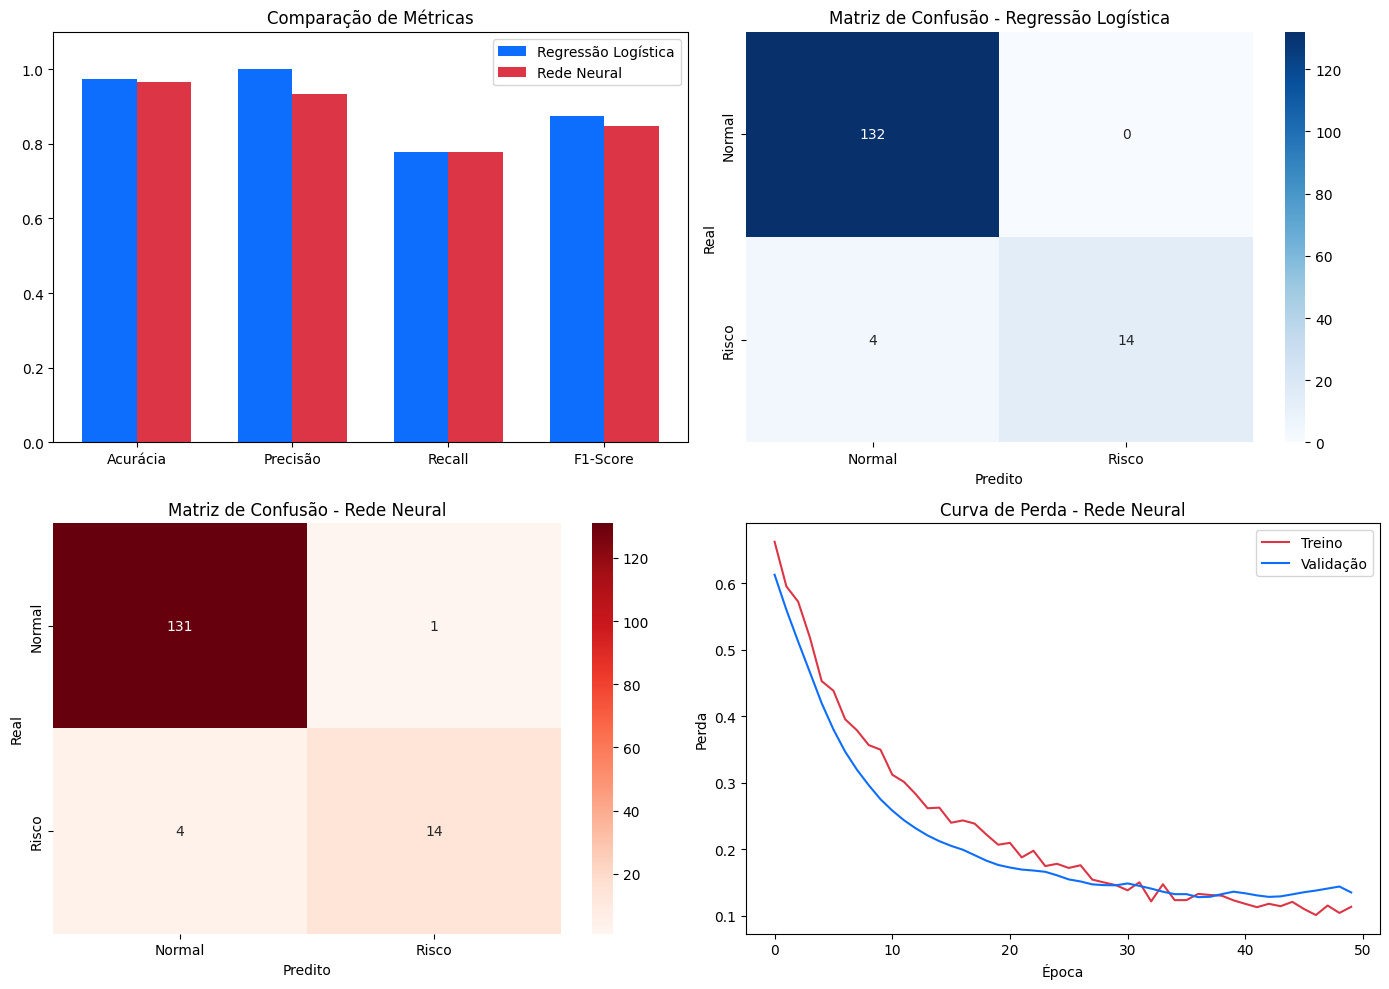

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Barras comparativas
x = np.arange(len(comparacao))
width = 0.35
axes[0,0].bar(x - width/2, comparacao['Regressão Logística'], width, label='Regressão Logística', color='#0d6efd')
axes[0,0].bar(x + width/2, comparacao['Rede Neural'], width, label='Rede Neural', color='#dc3545')
axes[0,0].set_xticks(x)
axes[0,0].set_xticklabels(comparacao['Métrica'])
axes[0,0].set_ylim(0, 1.1)
axes[0,0].set_title('Comparação de Métricas')
axes[0,0].legend()

# Matriz de confusão - RL
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0,1],
            xticklabels=['Normal', 'Risco'], yticklabels=['Normal', 'Risco'])
axes[0,1].set_title('Matriz de Confusão - Regressão Logística')
axes[0,1].set_ylabel('Real')
axes[0,1].set_xlabel('Predito')

# Matriz de confusão - RN
cm_nn = confusion_matrix(y_test, y_pred_nn)
sns.heatmap(cm_nn, annot=True, fmt='d', cmap='Reds', ax=axes[1,0],
            xticklabels=['Normal', 'Risco'], yticklabels=['Normal', 'Risco'])
axes[1,0].set_title('Matriz de Confusão - Rede Neural')
axes[1,0].set_ylabel('Real')
axes[1,0].set_xlabel('Predito')

# Curva de perda da RN
axes[1,1].plot(history.history['loss'], label='Treino', color='#dc3545')
axes[1,1].plot(history.history['val_loss'], label='Validação', color='#0d6efd')
axes[1,1].set_title('Curva de Perda - Rede Neural')
axes[1,1].set_xlabel('Época')
axes[1,1].set_ylabel('Perda')
axes[1,1].legend()

plt.tight_layout()
plt.show()

In [14]:
metricas = [acc_lr, prec_lr, rec_lr, f1_lr]
metricas_nn = [acc_nn, prec_nn, rec_nn, f1_nn]
lr_vence = sum(m > m_nn for m, m_nn in zip(metricas, metricas_nn))
nn_vence = sum(m_nn > m for m, m_nn in zip(metricas, metricas_nn))

print("=" * 55)
print("   COMPARAÇÃO FINAL - IR ALÉM 2")
print("=" * 55)
print(f"\nRegressão Logística venceu em {lr_vence}/4 métricas")
print(f"Rede Neural venceu em {nn_vence}/4 métricas")

if nn_vence > lr_vence:
    vencedor, motivo = "Rede Neural", "melhor capacidade de capturar padrões não-lineares"
elif lr_vence > nn_vence:
    vencedor, motivo = "Regressão Logística", "modelo mais simples e estável"
else:
    vencedor, motivo = "Empate técnico", "ambos apresentaram desempenho semelhante"

print(f"\n🏆 Vencedor: {vencedor}")
print(f"📌 Motivo: {motivo}")
print(f"\n⏱️ Regressão Logística: treino em segundos")
print(f"⏱️ Rede Neural: treino em minutos, maior complexidade")

   COMPARAÇÃO FINAL - IR ALÉM 2

Regressão Logística venceu em 3/4 métricas
Rede Neural venceu em 0/4 métricas

🏆 Vencedor: Regressão Logística
📌 Motivo: modelo mais simples e estável

⏱️ Regressão Logística: treino em segundos
⏱️ Rede Neural: treino em minutos, maior complexidade


## Conclusão

A comparação mostra que:

- **Regressão Logística** é mais rápida, simples e interpretável — ideal para dispositivos IoT como ESP32
- **Rede Neural** captura relações mais complexas, mas exige mais recursos computacionais
- Para detecção de risco cardíaco com dados tabulares (BPM, temperatura), a Regressão Logística oferece o melhor custo-benefício

## Como usar no seu GitHub

1. Rode todas as células em ordem: **Runtime → Run all**
2. Baixe: **File → Download → Download .ipynb**
3. No GitHub do projeto, vá em `notebooks/` → **Add file → Upload files**
4. Nomeie como `ir_alem2_comparacao_ia.ipynb`
5. Commit: `feat: ir além 2 - comparação de modelos IA`